In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/store-sales-time-series-forecasting/oil.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/sample_submission.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/holidays_events.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/stores.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/test.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/transactions.csv


# Store Sales - Time Series Forecasting 

## Objective of the Project 

The goal of this project is to build a **time-series forecasting model** that predicts the number of units sold for thousands of products across multiple grocery stores.

Using historical sales data from Corporación Favorita, the model will learn patterns in **dates, store information, item categories, and promotional activities** to accurately forecast future sales.

This project focuses on applying machine learning techniques to retail demand forecasting. By analyzing past sales behavior and temporal patterns, the model aims to improve prediction accuracy for daily product sales.

Accurate sales forecasting is critical for retail businesses because it helps:

- Optimize **inventory management**
- Reduce **overstock and product waste**
- Prevent **stockouts of popular products**
- Improve **overall customer satisfaction**

Through this project, we explore how **data-driven forecasting models** can support better decision-making in retail operations.

## 1. Packages

In [2]:
import pandas as pd 
import numpy as np
import os 
import gc
import warnings 

import statsmodels.api as sm 

import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format
warnings.filterwarnings('ignore')

The following libraries are used for data manipulation, statistical analysis, visualization, and system utilities throughout this notebook.

## 2. Importing Data 

In [3]:
train = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv")
test = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/test.csv")
stores = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/stores.csv")
transaction = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/transactions.csv")

# Convert to datetime 
train['date'] = pd.to_datetime(train.date)
test['date']  = pd.to_datetime(test.date)
transaction['date'] = pd.to_datetime(transaction.date)

# Data types
train.onpromotion = train.onpromotion.astype("float16")
train.sales = train.sales.astype("float32")
stores.cluster = stores.cluster.astype('int8')

train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0.00
1,1,2013-01-01,1,BABY CARE,0.00,0.00
2,2,2013-01-01,1,BEAUTY,0.00,0.00
3,3,2013-01-01,1,BEVERAGES,0.00,0.00
4,4,2013-01-01,1,BOOKS,0.00,0.00


In [4]:
transaction.head(10)

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922
5,2013-01-02,5,1903
6,2013-01-02,6,2143
7,2013-01-02,7,1874
8,2013-01-02,8,3250
9,2013-01-02,9,2940


In [5]:
train1 = train.groupby(["date", "store_nbr"])["sales"].sum().reset_index()
train1.head()

,date,store_nbr,sales
0,2013-01-01,1,0.00
1,2013-01-01,2,0.00
2,2013-01-01,3,0.00
3,2013-01-01,4,0.00
4,2013-01-01,5,0.00


### Total sales over time 

In [6]:
daily_sales = train1.groupby("date")["sales"].sum().reset_index()
fig = px.line(
    daily_sales,
    x="date",
    y="sales",
    title="Total Sales Over Time"
)

fig.show()

> Trend : The overall sales show a **clear upward trend over time**. From 2013 to 2017, total sales gradually increase, indicating that the business is expanding or customer demand is growing. This long-term growth trend suggest that the retail chain is experiencing increasing sales volumne across stores and product categories.
>
> Summary:
> From the visualization, we can conclude that:
> - The data shows a **strong upward trend** in sales over time.
> - There is **clear seasonal behaviour** with regular repeating peaks.
> - A few **outliers or abnormal drops** appear, likely caused by special events or store closures.


### Sales by Store

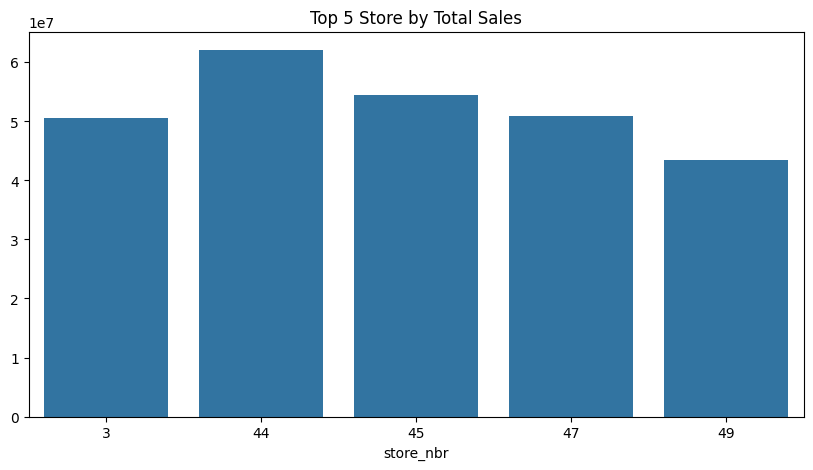

In [7]:
store_sales = train1.groupby("store_nbr")["sales"].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(10,5))
sns.barplot(x=store_sales.index, y=store_sales.values)
plt.title("Top 5 Store by Total Sales")
plt.show()

> Top 5 Stores by Total Sales
> The chart above shows the five stores with the highest total sales in the dataset. These stores contribute the largest share of revenue and likely represent high-demand locations with strong customer traffic. Understand which stores generate the most sales can help support better demand forcasting across the network.

### Weekly Sales Pattern

In [8]:
train["day_of_week"] = train["date"].dt.dayofweek
train["month"] = train["date"].dt.month
train["year"] = train["date"].dt.year

In [9]:
train["day_of_week"] = train["date"].dt.dayofweek

In [10]:
weekly_sales = (
    train.groupby("day_of_week")["sales"]
    .mean()
    .reset_index()
)

In [11]:
fig = px.bar(
    weekly_sales,
    x="day_of_week",
    y="sales",
    title="Average Sales by Day of Week",
    labels={
        "day_of_week": "Day of Week",
        "sales": "Average Sales"
    }
)

fig.update_layout(template="plotly_white")

fig.show()

The chart shows how sales vary across different days of the week.
Retail sales often increase during weekends due to higher customer traffic, while weekdays may show lower demand.

### Monthly Seasonality

In [12]:
train["month"] = train["date"].dt.month
monthly_sales = (
    train.groupby("month")["sales"]
    .mean()
    .reset_index()
)
fig = px.line(
    monthly_sales,
    x="month",
    y="sales",
    markers=True,
    title="Average Sales by Month"
)

fig.update_layout(template="plotly_white")

fig.show()

Monthly sales patterns reveal seasonal fluctuations throughout the year.
Certain months may experience higher demand due to holidays, promotional campaigns, or seasonal consumer behavior.


## 3. Building Models

In [13]:
train["day_of_week"] = train["date"].dt.dayofweek
train["month"] = train["date"].dt.month
train["year"] = train["date"].dt.year
train["family"] = train["family"].astype("category").cat.codes

### Choose features

In [14]:
features = [
    "store_nbr",
    "family",
    "onpromotion",
    "day_of_week",
    "month",
    "year"
]

target = "sales"

### Train / validation split

In [15]:
split_date = "2017-01-01"

train_data = train[train["date"] < split_date]
valid_data = train[train["date"] >= split_date]

# Create X and y
X_train = train_data[features]
y_train = train_data[target]

X_valid = valid_data[features]
y_valid = valid_data[target]

### Train LightGBM

In [16]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    random_state=42
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse",
)

lgb_pred = lgb_model.predict(X_valid)

rmse_lgb = np.sqrt(mean_squared_error(y_valid, lgb_pred))
print("LightGBM RMSE:", rmse_lgb)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049236 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 307
[LightGBM] [Info] Number of data points in the train set: 2596374, number of used features: 6
[LightGBM] [Info] Start training from score 338.713869
LightGBM RMSE: 381.0233234873632


### CatBoost Model

In [17]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    random_seed=42,
    verbose=100
)

cat_model.fit(X_train, y_train)

cat_pred = cat_model.predict(X_valid)

rmse_cat = np.sqrt(mean_squared_error(y_valid, cat_pred))
print("CatBoost RMSE:", rmse_cat)

0:	learn: 1024.7473128	total: 258ms	remaining: 4m 18s
100:	learn: 500.7324159	total: 17.2s	remaining: 2m 33s
200:	learn: 446.9477148	total: 33.9s	remaining: 2m 14s
300:	learn: 418.3239325	total: 51.1s	remaining: 1m 58s
400:	learn: 398.9254099	total: 1m 8s	remaining: 1m 41s
500:	learn: 383.5123803	total: 1m 25s	remaining: 1m 25s
600:	learn: 371.6890924	total: 1m 42s	remaining: 1m 8s
700:	learn: 361.8167437	total: 1m 59s	remaining: 51s
800:	learn: 353.8194760	total: 2m 16s	remaining: 33.9s
900:	learn: 346.7316777	total: 2m 33s	remaining: 16.9s
999:	learn: 340.5241271	total: 2m 50s	remaining: 0us
CatBoost RMSE: 409.90258173440793


### XG Boost

In [18]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=100
)

xgb_pred = xgb_model.predict(X_valid)

rmse_xgb = np.sqrt(mean_squared_error(y_valid, xgb_pred))
print("XGBoost RMSE:", rmse_xgb)

[0]	validation_0-rmse:1319.21128
[100]	validation_0-rmse:479.39312
[200]	validation_0-rmse:419.14394
[300]	validation_0-rmse:406.82563
[400]	validation_0-rmse:396.68715
[500]	validation_0-rmse:396.58832
[600]	validation_0-rmse:394.23271
[700]	validation_0-rmse:396.78665
[800]	validation_0-rmse:402.09309
[900]	validation_0-rmse:406.45732
[999]	validation_0-rmse:413.73310
XGBoost RMSE: 413.73310010802857


### Ensemble Model (LightGBM + XGBoost + CatBoost)

In [19]:
ensemble_pred = (lgb_pred + xgb_pred + cat_pred) / 3

rmse_ensemble = np.sqrt(mean_squared_error(y_valid, ensemble_pred))

print("Ensemble RMSE:", rmse_ensemble)

Ensemble RMSE: 383.14808705428356


### Compare 3 Models and Ensemble Model

In [20]:
print("LightGBM RMSE:", rmse_lgb)
print("XGBoost RMSE:", rmse_xgb)
print("CatBoost RMSE:", rmse_cat)
print("Ensemble RMSE:", rmse_ensemble)

LightGBM RMSE: 381.0233234873632
XGBoost RMSE: 413.73310010802857
CatBoost RMSE: 409.90258173440793
Ensemble RMSE: 383.14808705428356


### Predict Test set

### Tạo feature giống train

In [21]:
test["day_of_week"] = test["date"].dt.dayofweek
test["month"] = test["date"].dt.month
test["year"] = test["date"].dt.year

Encode family

In [22]:
test["family"] = test["family"].astype("category").cat.codes

Tạo X_test

In [23]:
X_test = test[features]

In [24]:
lgb_pred = lgb_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)
cat_pred = cat_model.predict(X_test)

test_pred = (lgb_pred + xgb_pred + cat_pred) / 3

submission = pd.DataFrame({
    "id": test["id"],
    "sales": test_pred
})

submission.to_csv("submission.csv", index=False)